# Figs. 1, S1K, S2A

In [ ]:
import pickle
from importlib import reload

import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

import numpy as np
import scipy.stats

import methods.util as util
import methods.shared as shared
import methods.sim_barcodes as sim
from methods.config import *

rnd = np.random.default_rng()

### For downstream analyses, identify high-frequency lineages and estimate early growth rates, compare SD to MD mice.

In [ ]:
reload(shared)
expt = 'E1'
fit_barcodes = {}
mouse_specific_high_frequency_barcodes = {}

mice_in_each_col = [(1,2,3,4,5), (6,7,8,9,10), (11,12,13)]

SD_growth_rates = {}
MD_growth_rates = {}
high_freq = 1e-2

for m_set in mice_in_each_col:
    for single_mouse in m_set:
        large_indices_before_3weeks = shared.find_large_barcodes(expt, 
                                                                 [single_mouse], 
                                                                 max_cutoff=high_freq, 
                                                                 final_cutoff=1, 
                                                                 max_timepoint=21)
        print(f'Mouse {single_mouse}: sampled {len(large_indices_before_3weeks)} high frequency (>{high_freq:.0e}) barcodes by day 21')
        days, reads, depths = shared.get_mouse_timecourse(expt, single_mouse, min_depth=10**4)
        freqs = shared.calc_freqs(reads, depths)

        large_indices= shared.find_large_barcodes(expt, [single_mouse], max_cutoff=1e-2, final_cutoff=1)
        mouse_specific_high_frequency_barcodes[single_mouse] = large_indices
        for barcode in shared.barcodes[large_indices]:
            if barcode not in fit_barcodes:
                fit_barcodes[barcode] = []
            fit_barcodes[barcode].append(single_mouse)

        if single_mouse in [4,5,6,7]: ## skip cross-housed mice
            continue
        if single_mouse in [1,2,3,8,9,10]:
            diet_growth_rates = SD_growth_rates
        elif single_mouse in [11,12,13]:
            diet_growth_rates = MD_growth_rates


        days, reads, depths = shared.get_mouse_timecourse(expt, single_mouse, min_depth=10**3)
        freqs = shared.calc_freqs(reads, depths)


        for barcode_idx in large_indices:
            barcode = shared.barcodes[barcode_idx]
            bc_freqs = freqs[:,barcode_idx]
            
            final_idx = np.where(bc_freqs > 10**-2)[0][0]
            try:
                init_idx = np.where(bc_freqs[:final_idx] < 10**-3)[0][-1]
            except IndexError:
                init_idx = 2
            t0, t1 = days[init_idx], days[final_idx]
            if t1 > 21:
                continue
            dt = t1-t0
            # print(f'  Barcode {barcode}: freq {bc_freqs[init_idx]:.2e} on day {t0}, freq {bc_freqs[final_idx]:.2e} on day {t1}')

            _, reads, [D0, D1] = shared.get_mouse_timecourse(expt, single_mouse, specific_timepoints=[t0, t1])
            f0,f1 = shared.calc_freqs(reads, np.array([D0, D1]))
            mm_f0, mm_f1 = shared.maxmin_freqs([f0[barcode_idx]], D0, [f1[barcode_idx]], D1)

            growth_rate = np.log(mm_f1/mm_f0)[0]/dt
            if barcode not in diet_growth_rates:
                diet_growth_rates[barcode] = []
            diet_growth_rates[barcode].append((single_mouse, growth_rate, (t0,t1), (f0*D0,f1*D1)))
            
SD_lst, MD_lst = [], []

for (diet, filtered_lst, diet_growth_rates) in [('SD', SD_lst, SD_growth_rates), ('MD', MD_lst, MD_growth_rates)]:
    for b, (barcode, bc_growths) in enumerate(diet_growth_rates.items()):
        growth_rates = np.array([g[1] for g in bc_growths]) 
        if len(growth_rates) == 0: continue
        filtered_lst.append(np.median(growth_rates))

    filtered_lst.sort(key=lambda x: x, reverse=True)
    
    print('\n')
    print(f'Diet {diet}: num high_freq barcodes (>{high_freq:.0e} in at least one mouse):', len(filtered_lst))
    print('List of growth rates:', [float(f'{g:.2f}') for g in filtered_lst])
    print('Min, max growth rate in first 3 weeks (/day):', f'{np.min(filtered_lst):.2f}, {np.max(filtered_lst):.2f}')
    print('25th, median, 75th percentile:', f'{np.percentile(filtered_lst[:10], 25):.2f}, {np.median(filtered_lst[:10]):.2f}, {np.percentile(filtered_lst[:10], 75):.2f}')

MD_lst, SD_lst = np.array(MD_lst), np.array(SD_lst)
MD_lst = np.sort(MD_lst)[::-1]
SD_lst = np.sort(SD_lst)[::-1] 
print('\n')
print('1-sided Mann Whitney test for MD > SD growths among top 10', scipy.stats.mannwhitneyu(MD_lst[:10], SD_lst[:10], alternative='greater'))

# for mouse in mouse_specific_high_frequency_barcodes:
#     print(f'Mouse {mouse}: {len(mouse_specific_high_frequency_barcodes[mouse])} high frequency barcodes')
#     print('List of barcodes:', [shared.barcodes[b] for b in mouse_specific_high_frequency_barcodes[mouse]])

with open(f'../data/pickled/E1_large_barcodes.pkl', 'wb') as f:
    pickle.dump(fit_barcodes, f)



Mouse 1: sampled 12 high frequency (>1e-02) barcodes by day 21
Mouse 2: sampled 11 high frequency (>1e-02) barcodes by day 21
Mouse 3: sampled 13 high frequency (>1e-02) barcodes by day 21
Mouse 4: sampled 18 high frequency (>1e-02) barcodes by day 21
Mouse 5: sampled 19 high frequency (>1e-02) barcodes by day 21
Mouse 6: sampled 13 high frequency (>1e-02) barcodes by day 21
Mouse 7: sampled 11 high frequency (>1e-02) barcodes by day 21
Mouse 8: sampled 18 high frequency (>1e-02) barcodes by day 21
Mouse 9: sampled 13 high frequency (>1e-02) barcodes by day 21
Mouse 10: sampled 9 high frequency (>1e-02) barcodes by day 21
Mouse 11: sampled 9 high frequency (>1e-02) barcodes by day 21
Mouse 12: sampled 10 high frequency (>1e-02) barcodes by day 21
Mouse 13: sampled 15 high frequency (>1e-02) barcodes by day 21


Diet SD: num high_freq barcodes (>1e-02 in at least one mouse): 65
List of growth rates: [3.58, 2.19, 1.34, 1.29, 1.24, 1.16, 1.1, 1.1, 1.07, 0.97, 0.97, 0.96, 0.96, 0.86, 0.86,

## Fig. 1 Muller plots, entropy and MFC dynamics

1 25 [ 0  1  2  3  4  5  6  7  9 12 14 15 16 17 18 19 20 21 22 27 29 33 36 40
 54]
2 23 [ 0  1  2  3  4  5  6  7  9 12 14 15 16 18 19 20 21 22 27 29 33 40 54]
3 23 [ 0  1  2  3  4  5  6  7  9 12 14 15 17 18 19 20 21 22 29 33 36 40 54]
8 28 [ 0  1  2  3  4  5  6  7  9 12 14 15 16 17 18 19 20 21 27 29 33 36 40 45
 46 47 48 54]
9 25 [ 0  1  2  3  4  5  6  7  9 12 14 16 17 18 19 20 21 22 27 33 36 40 47 48
 54]
10 23 [ 0  1  2  3  4  5  6  7  9 12 14 16 17 18 19 20 22 29 33 40 46 48 54]
11 20 [ 0  1  2  3  4  6  9 12 14 15 16 17 18 19 20 22 27 29 33 51]
12 20 [ 0  1  2  3  4  5  6  7  9 12 14 15 16 17 19 20 27 29 40 51]
13 14 [ 0  2  3  4  6  9 15 17 19 20 21 27 29 40]
Num barcodes considered for lfc calculation in SD (P2), mouse 1: 8707 	 83.8% of input barcodes, freq range = (2.67e-05, 5.65e-04)
Num barcodes considered for lfc calculation in SD (P2), mouse 2: 8707 	 83.8% of input barcodes, freq range = (2.67e-05, 5.65e-04)
Num barcodes considered for lfc calculation in SD (P2), mouse 3: 

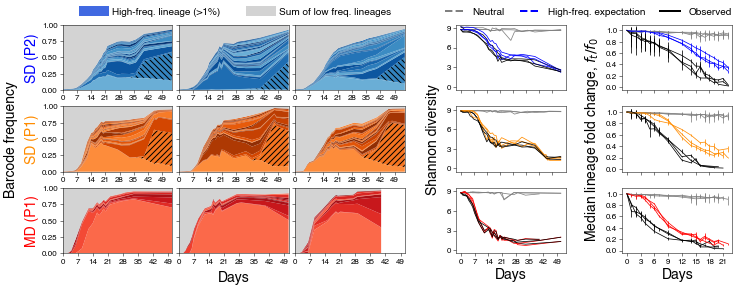

In [ ]:
reload(shared)
expt = 'E1'

fig = plt.figure(figsize=(12, 4.5))
all_gs = mpl.gridspec.GridSpec(nrows=2, ncols=2, height_ratios=[0.1, 3], width_ratios=(3.5, 2.5), hspace=0.07, figure=fig)

outer = all_gs[1, :].subgridspec(nrows=3, ncols=7, wspace=0.07, hspace=0.25, width_ratios=(1,1,1,0.35,1,0.4,1))
outer_ax = fig.add_subplot(outer[:, :3])
outer_ax.set_xlabel('Days', fontsize=14, labelpad=17)
outer_ax.set_ylabel('Barcode frequency', fontsize=14, labelpad=45)
util.turn_off_ax(outer_ax)

legend_ax = fig.add_subplot(all_gs[0,0])
util.turn_off_ax(legend_ax)
legend_markers = [ mpl.lines.Line2D((0,), (0,), color='royalblue',  linestyle='solid', lw=10),
                    mpl.lines.Line2D((0,), (0,), color='lightgrey', linestyle='solid', lw=10),]
legend_ax.legend(legend_markers, ['High-freq. lineage (>1%)', 'Sum of low freq. lineages'] , loc=(0.05, -0.5), ncol=2, frameon=False, fontsize=10, columnspacing=3)


mean_fitness_traj = {}

mice_in_each_row = [(1,2,3), (8,9,10), (11,12,13)]

muller_colors = {'SD (P2)':'blue', 'SD (P1)':'darkorange', 'MD (P1)':'red'}
for row, (mice_set, colormaps, title) in enumerate( zip(mice_in_each_row, 

                                                  [(('P2', 'Blues'), ('P1', 'Oranges'), ('E1_shared', 'Greys'), ('E1_ambiguous', 'Greys')),
                                                   (('P2', 'Blues'), ('P1', 'Oranges'), ('E1_shared', 'Greys'), ('E1_ambiguous', 'Greys')),
                                                   (('P2', 'Reds'), ('P1', 'Reds'), ('E1_shared', 'Greys'), ('E1_ambiguous', 'Greys'))], 
                                                   
                                                  ['SD (P2)', 'SD (P1)', 'MD (P1)']) ):
    large_indices = shared.find_large_barcodes(expt, mice_set, max_cutoff=1e-2, final_cutoff=2)

    
    ordered_indices, ordered_colors = shared.order_barcodes_by_pool(large_indices, shared.barcode_pool_assignments,
                                                                     colormaps, cg_at_end=True, cg_all_low_freqs=True)
    for col, mouse in enumerate(mice_set):
        days, freqs = shared.make_muller_freqs(expt, mouse, ordered_indices, 18, min_depth=10**4)
        print(mouse, len(days), days)
        ax = fig.add_subplot(outer[row, col])
        shared.muller_plot(ax, days, ordered_indices, freqs, ordered_colors, shared.highlight_barcode_hatches)

        if 'format':
            ax.set_ylim(0, 1)
            ax.set_xlim(0, 54)
            ax.set_xticks([0, 7, 14, 21, 28, 35, 42, 49])
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

            ax.spines['top'].set_linewidth(0.5)
            ax.spines['right'].set_linewidth(0.5)
            ax.spines['bottom'].set_linewidth(0.5)
            ax.spines['left'].set_linewidth(0.5)
            ax.tick_params(axis='x', direction='out', width=0.5, length=3)
            ax.tick_params(axis='y', direction='out', width=0.5, length=3)

            if row == 2:
                ax.set_xlim(0, 51)
            if col == 0:
                ax.set_ylabel(title, color=muller_colors[title], fontsize=14, labelpad=3)
            if col > 0:
                ax.set_yticklabels([])

# Diversity and median fold-change panels.
legend_ax = fig.add_subplot(all_gs[0, 1])
util.turn_off_ax(legend_ax)
legend_markers = [
                    mpl.lines.Line2D((0,), (0,), color='grey', linestyle='dashed', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='blue', linestyle='dashed', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='black', mfc='None', markersize=4, lw=2)]
legend_ax.legend(legend_markers, ['Neutral', 'High-freq. expectation', 'Observed'], loc=(-0.15, -0.5), ncol=3, frameon=False, fontsize=10, columnspacing=1.5)


entropy_outer = fig.add_subplot(outer[:, 4])
util.turn_off_ax(entropy_outer)
entropy_outer.set_ylabel('Shannon diversity', fontsize=14, labelpad=16)
entropy_outer.set_xlabel('Days', fontsize=14, labelpad=14)

median_fc_outer = fig.add_subplot(outer[:, 6])
util.turn_off_ax(median_fc_outer)
median_fc_outer.set_ylabel('Median lineage fold change, $f_t/f_0$', fontsize=14, labelpad=21)
median_fc_outer.set_xlabel('Days', fontsize=14, labelpad=14)

min_freq = 0
Ntau = 10**6 #days
MIN_GROUP_SIZE = 30
for z, (m_set, colors, inoc_bool, title) in enumerate( zip(mice_in_each_row, 
                                                ['blue', 'darkorange', 'red'],
                                                [shared.barcode_pool_assignments['P2'][1], shared.barcode_pool_assignments['P1'][1], shared.barcode_pool_assignments['P1'][1]],
                                                ['SD (P2)', 'SD (P1)', 'MD (P1)']) ):
    entropy_ax = fig.add_subplot(outer[z, 4])
    ax = fig.add_subplot(outer[z, 6])


    for m, mouse in enumerate(m_set):
        plot_days, mouse_reads, mouse_depths = shared.get_mouse_timecourse(expt, mouse)
        mouse_freqs = shared.calc_freqs(mouse_reads, mouse_depths)



        mouse_large_entropies = shared.calc_entropy(mouse_freqs, min_freq=min_freq)

        neutral_sim_frequencies = sim.neutral_sim(mouse_freqs[0], Ntau, plot_days, mouse_depths)
        expected_neutral_entropies = shared.calc_entropy(neutral_sim_frequencies, min_freq=min_freq)

        high_frequency_expected_freqs = shared.high_frequency_expectation(plot_days, mouse_freqs, 
                                                                          mouse_specific_high_frequency_barcodes[mouse], mouse_depths, Ntau=Ntau) 
        
        expected_large_entropies = shared.calc_entropy(high_frequency_expected_freqs, min_freq=min_freq)

        
        large_Deff = ((mouse_depths > 10**4) | ( (plot_days >= 14) & (mouse_depths > 10**3))) #plot entropy points with sufficient sequencing depth
        entropy_ax.plot(plot_days[large_Deff], expected_neutral_entropies[large_Deff], color='grey', linestyle='solid', zorder=0)
        entropy_ax.plot(plot_days[large_Deff], expected_large_entropies[large_Deff], color=colors, linestyle='solid', alpha=1)
        entropy_ax.plot(plot_days[large_Deff], mouse_large_entropies[large_Deff], color='black', linestyle='solid')

    

        # Group lineages by initial read count.
        day0_reads = mouse_reads[0]
        day0_freqs = mouse_freqs[0]
        barcode_groups = []
        barcode_ranges = []


        lower = np.percentile(day0_reads[inoc_bool], 75)
        max_reads = np.percentile(day0_reads[inoc_bool], 99.9)


        input_total_represented = np.sum(day0_freqs[inoc_bool][ (day0_reads[inoc_bool] > lower) & (day0_reads[inoc_bool] < max_reads)])

        upper = lower * 1.1
        
        while upper < max_reads:
            indices = np.where( (day0_reads >= lower) & (day0_reads < upper) )[0]
            if len(indices) < MIN_GROUP_SIZE:
                upper *= 1.1
                continue
            barcode_ranges.append( (lower, upper) )
            lower = upper
            upper = lower * 1.1
            barcode_groups.append(indices)

        min_freq, max_freq = np.min(barcode_ranges)/day0_reads.sum(), np.max(barcode_ranges)/day0_reads.sum()
        print( f'Num barcodes considered for lfc calculation in {title}, mouse {mouse}:', np.sum([len(g) for g in  barcode_groups]), f'\t {input_total_represented*100:.1f}% of input barcodes, freq range = ({min_freq:.2e}, {max_freq:.2e})' )

        for freqs, color, ls in zip([neutral_sim_frequencies, high_frequency_expected_freqs, mouse_freqs], 
                                    ['grey', colors, 'black'], 
                                    ['solid', 'solid', 'solid']):
            median_lfcs = shared.calc_median_lfc(freqs, mouse_depths, barcode_groups=barcode_groups)
            x, y, yerr = [0], [1], [[0, 0]]
            for day, depth, median_lfcs_in_groups in zip(plot_days[1:], mouse_depths[1:], median_lfcs):
                if day > 25 or len(median_lfcs_in_groups) < 4 or depth < 10**4:
                    continue

                medians = [median for (median, group_lfcs) in median_lfcs_in_groups]
                lfcs = [group_lfcs for (median, group_lfcs) in median_lfcs_in_groups]
                median_of_medians = np.exp(np.median(medians))
                quartiles = np.exp([np.percentile(medians, 25), np.percentile(medians, 75)])
                deltas = [median_of_medians- quartiles[0], quartiles[1] - median_of_medians]

                x.append(day)
                y.append(median_of_medians)
                yerr.append(deltas)
            
            ax.errorbar(x, y, yerr=np.transpose(yerr), color=color, ls=ls)
            if color == 'black':
                mean_fitness_traj[mouse] = (x, y, yerr)

    if 'format':
        entropy_ax.set_ylim(-0.5, 9.5)
        entropy_ax.set_xticks([0,7,14,21,28,35,42,49])
        entropy_ax.set_yticks([0, 3, 6, 9])

        ax.set_ylim(-0.05, 1.1)
        ax.set_xlim(-1, 23)
        ax.set_xticks([0,3,6,9,12,15,18,21])
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        entropy_ax.tick_params(axis='x', direction='out', width=0.5, length=3)
        entropy_ax.tick_params(axis='y', direction='out', width=0.5, length=3)
        ax.tick_params(axis='x', direction='out', width=0.5, length=3)
        ax.tick_params(axis='y', direction='out', width=0.5, length=3)

        ax.spines['top'].set_linewidth(0.5)
        ax.spines['right'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        ax.spines['left'].set_linewidth(0.5)

        entropy_ax.spines['top'].set_linewidth(0.5)
        entropy_ax.spines['right'].set_linewidth(0.5)
        entropy_ax.spines['bottom'].set_linewidth(0.5)
        entropy_ax.spines['left'].set_linewidth(0.5)

        if z != 2:
            ax.set_xticklabels([])
            entropy_ax.set_xticklabels([])
fig.savefig(f'../figures/fig1_E1_muller.pdf', bbox_inches='tight', transparent=True, dpi=300)
fig.savefig(f'../figures/fig1_E1_muller.svg', bbox_inches='tight', transparent=True, dpi=300)

with open(f'../data/pickled/E1_mean_fitness_traj.pkl', 'wb') as f:
    pickle.dump(mean_fitness_traj, f)

### Lower bound on adaptive lineages needed to explain median fold change.


In [16]:
for mice, median_fold_change in zip([[1,2,3,4,5], [6,7,8,9,10], [11,12,13]], 
                                    [0.7, 0.5, 0.3]):
    for m in mice:
        if m <= 5:
            plate = 'P2'
        else:
            plate = 'P1'

        try:
            a = mouse_specific_high_frequency_barcodes[m]
            bc = shared.barcode_pool_assignments[plate][1]
            mouse_timepoints, mouse_reads, mouse_depths = shared.get_mouse_timecourse(expt, m, specific_timepoints=[0, 9])
            freqs = shared.calc_freqs(mouse_reads, mouse_depths)
            f0 = freqs[0]  
            f1 = freqs[1]
            fc = f1[bc] / f0[bc]
        except:
            continue

        sorting = np.argsort(f1[bc])[::-1] #sort from largest to smallest
        cum_freq0, cum_freq, n_bc = 0, 0, 0
        flag = False
        for f, finit, fold_change, idx in zip(f1[bc][sorting], f0[bc][sorting], fc[sorting], sorting):
            if idx in a or fold_change > 1:
                cum_freq += f
                cum_freq0 += finit
                n_bc += 1
            if (1-cum_freq)/(1-cum_freq0) < median_fold_change:
                flag = True
                break
        if flag:
            print(f"Mouse {m}, MFC at day 9 = {median_fold_change}, accounted for by >{n_bc} adaptive lienages")

/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_25992/751601015.py:16: RuntimeWarning: divide by zero encountered in divide
  fc = f1[bc] / f0[bc]
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_25992/751601015.py:16: RuntimeWarning: invalid value encountered in divide
  fc = f1[bc] / f0[bc]


Mouse 1, MFC at day 9 = 0.7, accounted for by >662 adaptive lienages
Mouse 2, MFC at day 9 = 0.7, accounted for by >481 adaptive lienages
Mouse 3, MFC at day 9 = 0.7, accounted for by >683 adaptive lienages
Mouse 4, MFC at day 9 = 0.7, accounted for by >580 adaptive lienages
Mouse 5, MFC at day 9 = 0.7, accounted for by >262 adaptive lienages
Mouse 6, MFC at day 9 = 0.5, accounted for by >893 adaptive lienages
Mouse 7, MFC at day 9 = 0.5, accounted for by >862 adaptive lienages
Mouse 8, MFC at day 9 = 0.5, accounted for by >1572 adaptive lienages
Mouse 9, MFC at day 9 = 0.5, accounted for by >2091 adaptive lienages
Mouse 10, MFC at day 9 = 0.5, accounted for by >1760 adaptive lienages
Mouse 11, MFC at day 9 = 0.3, accounted for by >2696 adaptive lienages
Mouse 12, MFC at day 9 = 0.3, accounted for by >3029 adaptive lienages
Mouse 13, MFC at day 9 = 0.3, accounted for by >336 adaptive lienages


## Fig. S1K: Locally adapted lineage examples.


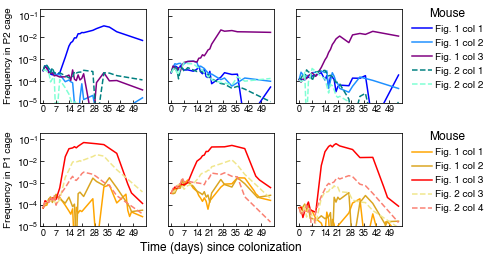

In [ ]:
mouse_colors = {1:'blue', 2:'dodgerblue', 3:'purple', 4:'teal', 5:'aquamarine',  8:'orange', 9:'goldenrod', 10:'red', 6:'khaki', 7:'salmon'}
relabel_mice = {1:'Fig. 1 col 1', 2:'Fig. 1 col 2', 3:'Fig. 1 col 3', 4:'Fig. 2 col 1', 5:'Fig. 2 col 2', 
                8:'Fig. 1 col 1', 9:'Fig. 1 col 2', 10:'Fig. 1 col 3', 6:'Fig. 2 col 3', 7:'Fig. 2 col 4'}
P2_examples = ['AACCTAATTGTACCGGTCCG', 'GGTACGAACGGTAACCCAGA', 'TAAGTACTTGGCGATTTTCT']
P1_examples = ['ACAAACATATCAGTGCTCTC', 'TGCGCACAGTGGTCACTCTC', 'TATGTTAGATAGGGATAAAC']

plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
fig = plt.figure(figsize=(6.5,4))
gs = plt.GridSpec(3, 3, height_ratios=(1, 0.05, 1))

for row, (mice, examples, cage) in enumerate(zip([[1,2,3,4,5], [8,9,10,6,7]], [P2_examples, P1_examples], ['P2 cage', 'P1 cage'])):
    for col, example_bc in enumerate(examples):
        ax = fig.add_subplot(gs[2*row, col])
        bc_index = np.where(shared.barcodes == example_bc)[0][0]

        for mouse in mice:
            ls = 'solid'
            if mouse in [4,5,6,7]:
                ls = '--'

            days, reads, depths = shared.get_mouse_timecourse(expt, mouse)
            freqs = shared.calc_freqs(reads, depths)

            ax.plot(days, freqs[:, bc_index] + 1e-6, label=f'{relabel_mice[mouse]}', color=mouse_colors[mouse], ls=ls, lw=1.5)
        ax.set_yscale('log')
        ax.set_ylim(1e-5, 2e-1)
        ax.set_xlim(-2, 56)
        ax.set_xticks([0, 7, 14, 21, 28, 35, 42, 49])
        ax.set_xticklabels([0, 7, 14, 21, 28, 35, 42, 49], fontsize=9)
        ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
        if col > 0:
            ax.set_yticklabels([])
        if col == 0:
            ax.set_ylabel(f'Frequency in {cage}', fontsize=10)
        if row == 1 and col == 1:
            ax.set_xlabel(f'Time (days) since colonization', fontsize=12)

        if col == 2:
            ax.legend(loc=(1.05, 0.1), ncol=1, title='Mouse', title_fontsize=12, fontsize=10, frameon=False, bbox_transform=ax.transAxes, handletextpad=0.3, columnspacing=1.0)

fig.savefig(f'../figures/sfig_monocolonization_locally_adapted_example.pdf', bbox_inches='tight', transparent=True)
fig.savefig(f'../figures/sfig_monocolonization_locally_adapted_example.svg', bbox_inches='tight', transparent=True)

### Simulation of neutral drift expectation for num. lineages exceeding 1% freq.

In [7]:
# Neutral expectation for lineages exceeding 1% frequency.
expt = 'E1'
Ntau = 1e6
freq_cutoff = 1e-2

for mice in [[1,2,3], [8,9,10], [11, 12, 13]]:
    for mouse in mice:
        min_depth = np.min([10**4, 3*freq_cutoff**-1.])

        days, reads, mouse_depths = shared.get_mouse_timecourse(expt, mouse, min_depth=min_depth)
        freqs = shared.calc_freqs(reads, mouse_depths)
        max_lst = []

        for _ in range(100):
            neutral_sim_frequencies = sim.neutral_sim(freqs[2], Ntau, days[2:], mouse_depths[2:]) 
            # Start from the deeply sampled day-2 state.
            max_freqs = np.max(neutral_sim_frequencies, axis=0)
            max_lst.append( (max_freqs > freq_cutoff).sum() )
        print(f'Mouse {mouse}, mean # neutral barcodes > {freq_cutoff*100}% freq:', np.mean(max_lst), ' std:', np.std(max_lst))

Mouse 1, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 2, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 3, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 8, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 9, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 10, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 11, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 12, mean # neutral barcodes > 1.0% freq: 0.0  std: 0.0
Mouse 13, mean # neutral barcodes > 1.0% freq: 0.02  std: 0.13999999999999999


## Fig. S2A, freq-thresholded lineage richness dynamics

129 barcodes above 0.0001 in mouse M1 at final timepoint
147 barcodes above 0.0001 in mouse M2 at final timepoint
101 barcodes above 0.0001 in mouse M3 at final timepoint


/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_25992/4161999168.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)


81 barcodes above 0.0001 in mouse M8 at final timepoint
69 barcodes above 0.0001 in mouse M9 at final timepoint
48 barcodes above 0.0001 in mouse M10 at final timepoint
73 barcodes above 0.0001 in mouse M11 at final timepoint
93 barcodes above 0.0001 in mouse M12 at final timepoint
77 barcodes above 0.0001 in mouse M13 at final timepoint


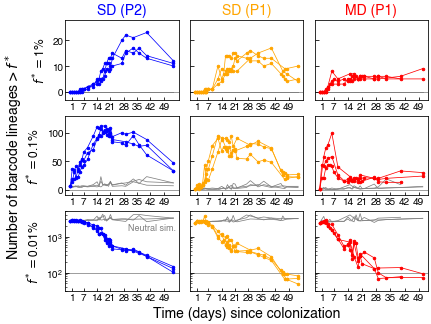

In [29]:
expt = 'E1'
Ntau = 10**6 # for simulated wright fisher

fig = plt.figure(figsize=(6.5, 5))
gs = plt.GridSpec(3,3, figure=fig, wspace=0.1)
outer_ax = fig.add_subplot(gs[:, :])
util.turn_off_ax(outer_ax)
outer_ax.set_ylabel(r'Number of barcode lineages > $f^*$', fontsize=14, labelpad=40)
outer_ax.set_xlabel(r'Time (days) since colonization', fontsize=14, labelpad=15)
                 
barcodes_above_1e4 = {}
null_barcodes_above_1e4 = {}
final_freqs_above_1e4 = []

axs = [[],[],[]]
for row, (cutoff, cutoff_label) in enumerate(zip([1e-2, 1e-3, 1e-4], ['1%', '0.1%', '0.01%'])):
    for col, (mice, label, color) in enumerate(zip([[1,2,3], [8,9,10], [11, 12, 13]],
                                                   ['SD (P2)', 'SD (P1)', 'MD (P1)'],
                                                   ['blue', 'orange', 'red'])):
        ax = fig.add_subplot(gs[row, col])
        axs[row].append(ax)

        min_depth = np.min([10**4, 3*cutoff**-1.])
        for mouse in mice:
            if row == 2:
                days, reads, depths = shared.get_mouse_timecourse(expt, mouse, min_depth=min_depth)
                freqs = shared.calc_freqs(reads, depths)
                final_freqs = freqs[-1]
                barcodes_above = np.where(final_freqs > cutoff)[0]
                final_freqs_above_1e4.append((freqs[0, barcodes_above], freqs[0]))
                for bc in barcodes_above:
                    if bc not in barcodes_above_1e4:
                        barcodes_above_1e4[bc] = []
                    barcodes_above_1e4[bc].append(mouse)

                    null_bc = rnd.choice(np.arange(len(shared.barcodes)))
                    if null_bc not in null_barcodes_above_1e4:
                        null_barcodes_above_1e4[null_bc] = []
                    null_barcodes_above_1e4[null_bc].append(mouse)

                    
                print(f"{len(barcodes_above)} barcodes above {cutoff} in mouse M{mouse} at final timepoint")

            days, n_barcodes_above_cutoff = shared.estimate_num_barcodes_above_cutoff('E1', mouse, cutoff, min_depth = min_depth)
            ax.plot(days[0], n_barcodes_above_cutoff[0], marker='.', linestyle='solid', color=color, markersize=5)
            sim_days, sim_n_barcodes_above_cutoff = shared.estimate_num_barcodes_above_cutoff_simulated('E1', mouse, cutoff, Ntau=Ntau, min_depth=min_depth)
            ax.plot(sim_days[0], sim_n_barcodes_above_cutoff[0], color='grey', linestyle='solid', zorder=0)

        ax.set_xticks([1, 7, 14, 21, 28, 35, 42, 49])
        ax.set_xticklabels([1, 7, 14, 21, 28, 35, 42, 49], fontsize=10)
        if row == 0:
            ax.set_title(label, color=color, fontsize=14)
            ax.set_ylim(-3, 28)
            ax.set_yticks([0, 10, 20])
            ax.axhline(0, color='grey', zorder=0)
        if row == 1:
            ax.set_ylim(-10, 130)
            ax.set_yticks([0, 50, 100])
            ax.axhline(0, color='grey', zorder=0)
        if row == 2:
            ax.set_ylim(30, 5000)
            ax.set_yticks([10**2, 10**3])
            ax.axhline(100, color='grey', zorder=0)
            ax.set_yscale('log')
        if col != 0:
            ax.set_yticklabels([])
        else:
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
            ax.set_ylabel(r'$f^*=$' + f'{cutoff_label}', fontsize=12)

        if row == 2 and col == 0:
            ax.text(0.98, 0.85, 'Neutral sim.', transform=ax.transAxes, color='grey', fontsize=9, ha='right', va='top')

fig.savefig(f'../figures/sfig_E1_mono_num_barcodes_above_cutoff.pdf', bbox_inches='tight', transparent=True)
fig.savefig(f'../figures/sfig_E1_mono_num_barcodes_above_cutoff.svg', bbox_inches='tight', transparent=True)